In [2]:
import pandas as pd

# load dataset
df = pd.read_csv('C:\\Users\\ridaa\\Downloads\\python project\\friends-nlp-project\\data\\archive (4)\\Friends.csv')

# check structure
print(df.head())
print(df.columns)
print(df.shape)


                                                Text  Speaker  \
0  Originally written by Marta Kauffman and David...      NaN   
1                          Transcribed by guineapig.      NaN   
2   CENTRAL PERK. (ALL PRESENT EXCEPT RACHEL AND ...  SCENE 1   
3   There's nothing to tell! He's just some guy I...   MONICA   
4   C'mon, you're going out with the guy! There's...     JOEY   

                                             Episode     Season     Show  
0  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
1  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
2  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
3  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
4  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
Index(['Text', 'Speaker', 'Episode', 'Season', 'Show'], dtype='object')
(69974, 5)


In [4]:
import pandas as pd

df = pd.read_csv('C:\\Users\\ridaa\\Downloads\\python project\\friends-nlp-project\\data\\archive (4)\\Friends.csv')

# 1. Drop rows where speaker is missing
df = df.dropna(subset=['Speaker'])

# 2. Remove rows where speaker is not a character (like SCENE)
df = df[~df['Speaker'].str.contains('SCENE', case=False)]

# 3. Strip whitespace
df['Speaker'] = df['Speaker'].str.strip()
df['Text'] = df['Text'].str.strip()

# 4. Remove very short lines (like noise)
df = df[df['Text'].str.len() > 5]

# 5. Keep only main characters (IMPORTANT for better model)
main_chars = ['JOEY', 'ROSS', 'CHANDLER', 'MONICA', 'RACHEL', 'PHOEBE']
df = df[df['Speaker'].isin(main_chars)]

# Reset index
df = df.reset_index(drop=True)

print(df.head())
print(df['Speaker'].value_counts())
print(df.shape)

                                                Text   Speaker  \
0  There's nothing to tell! He's just some guy I ...    MONICA   
1  C'mon, you're going out with the guy! There's ...      JOEY   
2    So does he have a hump? A hump and a hairpiece?  CHANDLER   
3                           Wait, does he eat chalk?    PHOEBE   
4  Just, 'cause, I don't want her to go through w...    PHOEBE   

                                             Episode     Season     Show  
0  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
1  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
2  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
3  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
4  Episode-01-The One Where Monica Gets a New Roo...  Season-01  Friends  
Speaker
ROSS        1315
CHANDLER    1048
MONICA      1033
JOEY        1005
RACHEL       930
PHOEBE       798
Name: count, dtype: int64
(6129, 5)


In [5]:
import re

# Improved catchphrases with flexible patterns
catchphrases = {
    "JOEY": [
        r"how\s+you\s+doin['g]?"
    ],
    "ROSS": [
        r"we\s+were\s+on\s+a\s+break"
    ],
    "CHANDLER": [
        r"could\s+i\s+be",
        r"could\s+that\s+be"
    ],
    "PHOEBE": [
        r"smelly\s+cat"
    ],
}

def preprocess(text):
    # lowercase + remove punctuation
    text = text.lower()
    text = re.sub(r"[^\w\s']", "", text)
    return text

def detect_catchphrase(text):
    clean_text = preprocess(text)

    for character, patterns in catchphrases.items():
        for pattern in patterns:
            if re.search(pattern, clean_text):
                return character, pattern

    return None, None


# Test
samples = [
    "How you doin?",
    "HOW YOU DOIN!!!",
    "We were on a break!",
    "we WERE on a break...",
    "Could I BE any more tired?",
    "Could that BE more obvious?",
    "I love smelly cat song",
]

for s in samples:
    print(s, "->", detect_catchphrase(s))

How you doin? -> ('JOEY', "how\\s+you\\s+doin['g]?")
HOW YOU DOIN!!! -> ('JOEY', "how\\s+you\\s+doin['g]?")
We were on a break! -> ('ROSS', 'we\\s+were\\s+on\\s+a\\s+break')
we WERE on a break... -> ('ROSS', 'we\\s+were\\s+on\\s+a\\s+break')
Could I BE any more tired? -> ('CHANDLER', 'could\\s+i\\s+be')
Could that BE more obvious? -> ('CHANDLER', 'could\\s+that\\s+be')
I love smelly cat song -> ('PHOEBE', 'smelly\\s+cat')


In [6]:
import random
import re

def friends_translator(text, character):
    text = text.strip()

    if not text:
        return "Say something!"

    lower_text = text.lower()

    if character == "JOEY":
        templates = [
            f"{text}... How you doin'?",
            f"{text}? How YOU doin'?",
        ]
        return random.choice(templates)

    elif character == "CHANDLER":
        word = lower_text.replace("i'm", "").replace("i am", "").strip()

        if not word:
            word = "this"

        templates = [
            f"Could I BE any more {word}?",
            f"Oh wow, could that BE any more {word}?",
            f"Could this situation BE any more {word}?"
        ]
        return random.choice(templates)

    elif character == "ROSS":
        if re.search(r"we\s+were\s+on\s+a\s+break", lower_text):
            return "WE WERE ON A BREAK!"

        templates = [
            f"{text}!!!",
            f"I mean, {text}...",
            f"{text}! This is unbelievable!",
        ]
        return random.choice(templates)

    elif character == "PHOEBE":
        # FIXED indentation + logic
        if "my eyes" in lower_text and lower_text.count("my eyes") >= 2:
            return "MY EYES! MY EYES!"

        templates = [
            f"{text}... but like in a weird, cosmic way.",
            f"{text}... ooooh that reminds me of a song!",
            f"This is brand new information!",
            f"{text}... but what if it's actually a spirit?"
        ]
        return random.choice(templates)

    elif character == "MONICA":
        templates = [
            f"{text}. Okay, we need a plan. RIGHT NOW.",
            f"{text}! This is completely out of control!",
            f"{text}. I’ll fix this.",
            f"{text}! I KNOW!"
        ]
        return random.choice(templates)

    elif character == "RACHEL":
        templates = [
            f"{text}?! No way!",
            f"Oh my God, {text}!",
            f"{text}... I can’t even.",
            f"{text}! Are you serious?"
        ]
        return random.choice(templates)

    else:
        return text

In [7]:
print(friends_translator("I'm tired", "CHANDLER"))
print(friends_translator("I'm hungry", "JOEY"))
print(friends_translator("This is unfair", "ROSS"))

Oh wow, could that BE any more tired?
I'm hungry? How YOU doin'?
I mean, This is unfair...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pickle

# 1. Fit vectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Text'])

# 2. Train model
model = LogisticRegression()
model.fit(X, df['Speaker'])  # or your label column

# 3. Save
with open('../models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Saved successfully")

Saved successfully


In [9]:
from sklearn.model_selection import train_test_split

X = df["Text"]
y = df["Speaker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.27814029363784665


In [13]:
df = df.dropna(subset=["Speaker", "Text"])

main_chars = ["ROSS", "CHANDLER", "MONICA", "JOEY", "RACHEL", "PHOEBE"]
df = df[df["Speaker"].isin(main_chars)]

# remove very short lines (like "hi", "ok")
df = df[df["Text"].str.len() > 10]

In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)  # remove stage directions
    text = re.sub(r"[^\w\s']", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["Text"].apply(clean_text)

In [15]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["Speaker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),   # 🔥 BIG BOOST
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.2911169744942832


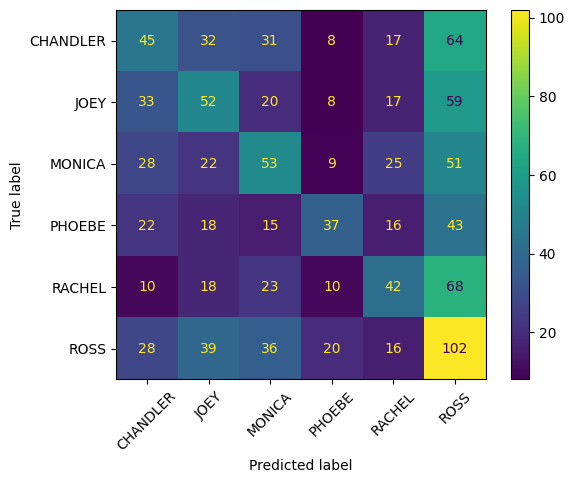

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.show()

In [20]:
# Remove invalid speakers
df = df.dropna(subset=["Speaker"])

# Keep only main characters
main_chars = ["ROSS", "CHANDLER", "MONICA", "JOEY", "RACHEL", "PHOEBE"]
df = df[df["Speaker"].isin(main_chars)]

# Remove junk text
df = df[df["Text"].str.len() > 10]

print(df.shape)  # should be around (6000, ...)

(5685, 6)


In [21]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)   # remove stage directions
    text = re.sub(r"[^\w\s']", "", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["Text"].apply(clean_text)

In [22]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["Speaker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 MUST HAVE
)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),   # 🔥 HUGE IMPACT
    max_features=8000,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [25]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2937554969217238


In [26]:
print(X_train.head())

5095    how do we say yes now and make it seem like we...
1882                                       oh oh chandler
2431                            yeah i guess you're right
3692               and the fact that they're both monkeys
5899    yeah i love that story um i got a question for...
Name: clean_text, dtype: object


In [27]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)   # remove stage directions
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [28]:
TfidfVectorizer(ngram_range=(1,2))

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [29]:
print(X_train_vec.shape)

(4548, 3625)


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",     # 🔥 removes useless words
    ngram_range=(1,2),        # 🔥 captures phrases
    min_df=2,                 # 🔥 removes rare noise
    max_df=0.9,               # 🔥 removes too frequent words
    max_features=8000         # 🔥 keeps strong features only
)

In [31]:
print(X_train_vec.shape)

(4548, 3625)


In [32]:
sublinear_tf=True

In [33]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    max_features=8000,
    sublinear_tf=True
)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2937554969217238


In [35]:
print(vectorizer)

TfidfVectorizer(max_df=0.9, max_features=8000, min_df=2, ngram_range=(1, 2),
                stop_words='english', sublinear_tf=True)


In [36]:
print(X_train_vec.shape)

(4548, 3625)


In [3]:
import pandas as pd
import re

# CLEAN
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["Text"].astype(str).apply(clean_text)

# FILTER
df = df[df["Speaker"].isin([
    "ROSS", "CHANDLER", "MONICA", "JOEY", "RACHEL", "PHOEBE"
])]

df = df[df["clean_text"].str.split().str.len() >= 5]

# SPLIT
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["Speaker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 🔥 VECTORIZER (fresh)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    max_features=8000,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("SHAPE:", X_train_vec.shape)

# MODEL
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_vec, y_train)

# EVAL
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)
print("ACCURACY:", accuracy_score(y_test, y_pred))

SHAPE: (3652, 3488)
ACCURACY: 0.30196936542669583
